In [1]:
"""This code takes some time to run due to the high number of sampled data points
Decrease T = 1000000 for quicker but less accurate empirical PDF
or reduce the number of points evaluated in the grid increasing the skip in minmax
from 5 e.g. to 10"""

#importing useful libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import ImageGrid
from sklearn.neighbors import KernelDensity
import matplotlib as mpl

#getting current directory
import os
cwd = os.getcwd()

#importing all the functions contained in "functions.py"
%run ../functions

In [22]:
#time lengths
delta_t = 0.01
T = 5

#define parameters of the three-state model
V = np.array([20, -15, 0])
Lambda = np.array([1, 0.5, 0.3])
P_A = np.array([[0.0, 0.2, 0.8], [0.3, 0.0, 0.7], [0.7, 0.3, 0.0]])

a = np.array([237/1441, 24/131, 940/1441])

Sigma = 5
sigma = 0
n = Lambda.shape[0]

t_sim_A_quick = np.arange(0,T+delta_t,delta_t)

In [23]:
N = 10

In [24]:
y_sim_A_quick = []
for i in range(N):
    y_sim_A_quick.append(n_state_model_with_random_IC(delta_t, T+delta_t, V, Lambda, P_A, a, Sigma, sigma, seed=1223+i*67)[1])

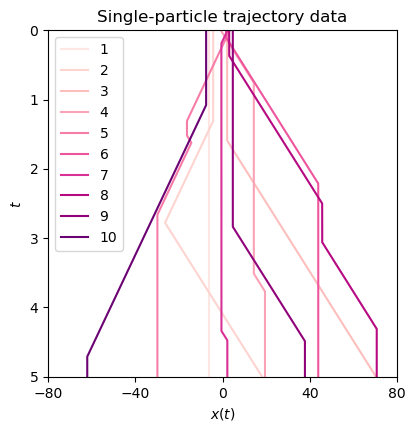

In [29]:
colors_list = mpl.colormaps['RdPu'](np.linspace(0, 1, N+2))[1:-1]

plt.figure(figsize=(4.5,4.5))
for i in range(N):
    plt.plot(y_sim_A_quick[i][:], t_sim_A_quick, '-', color=colors_list[i], label=str(i+1))

plt.title('Single-particle trajectory data')
plt.xlabel('$x(t)$')
plt.ylabel('$t$')
plt.ylim([0, T])
#plt.xlim([-40,40])
#plt.yticks([0,1,2])
plt.xticks([-80, -40, 0, 40, 80])
plt.legend()
plt.gca().invert_yaxis()

plt.savefig("Figure_1A.png",
            format="png", bbox_inches="tight", dpi=600)